# Dimensionality Reduction: PCA & t-SNE
### Hack-o-Week | ArpitaBuilds

**Covers:** PCA (Principal Component Analysis) and t-SNE — intuition, applications, and how each
reduces/visualizes high-dimensional data.

**Datasets used:**
- **Breast Cancer Wisconsin** (30 features) — for PCA, since PCA works best showing how a moderate
  number of correlated numeric features compress into 2 dimensions
- **Digits** (64 features — 8×8 pixel images of handwritten digits 0-9) — for t-SNE, since it's the
  classic example of t-SNE untangling complex, non-linear structure that PCA can't

Both are real datasets built into scikit-learn — no downloading needed.

**Why this matters for your project:** your stroke dataset has multiple numeric features (age, BMI,
glucose, blood pressure, etc.) — more than 2 or 3, which means you can't directly *plot* your patients
to see structure. PCA and t-SNE are exactly the tools that compress many features down to 2D so you
can **visualize** whether stroke and non-stroke patients naturally separate — a great exploratory
figure for your project report, even before training a classifier.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.rcParams['figure.figsize'] = (6, 5)
print("Setup done ✅")

Setup done ✅


---
## 1. Why Reduce Dimensions At All?

Your stroke dataset might have 10+ numeric columns (age, bmi, glucose, hypertension, heart disease,
etc.). Each column is a "dimension." Humans can visually understand 2D or 3D plots easily — but not
10D. We can't literally *see* 10 dimensions.

**Dimensionality reduction** compresses many features into just 2 (or 3) new features that preserve as
much of the important structure/pattern as possible, so we can plot and understand it.

Two very different approaches:
- **PCA** — finds directions of maximum *variance*, keeps everything linear and mathematically exact
- **t-SNE** — focuses on keeping *similar points close together*, even if it distorts distances
  elsewhere; better for visualization, not for feeding into another model afterward

---
## 2. PCA (Principal Component Analysis)

Recall from the linear algebra notebook: **eigenvectors** of a matrix are directions that don't get
rotated by a transformation, just scaled. PCA computes the eigenvectors of your data's **covariance
matrix** — these eigenvectors are the directions along which your data varies the *most*.

The first eigenvector (highest eigenvalue) = **Principal Component 1 (PC1)**: the single direction
that captures the most spread in the data. PC2 is the next-best direction, perpendicular to PC1, and
so on. Keeping just PC1 and PC2 gives you a 2D snapshot that preserves as much of the original
variance as mathematically possible in 2 dimensions.

In [2]:
data = load_breast_cancer()
X = data.data          # 30 features
y = data.target        # 0 = malignant, 1 = benign

# PCA is scale-sensitive (like Logistic Regression/KNN) - always scale first
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape: ", X_pca.shape)
print("Variance explained by PC1:", round(pca.explained_variance_ratio_[0] * 100, 1), "%")
print("Variance explained by PC2:", round(pca.explained_variance_ratio_[1] * 100, 1), "%")
print("Total variance captured in just 2D:", round(pca.explained_variance_ratio_[:2].sum() * 100, 1), "%")

Original shape: (569, 30)
Reduced shape:  (569, 2)
Variance explained by PC1: 44.3 %
Variance explained by PC2: 19.0 %
Total variance captured in just 2D: 63.2 %


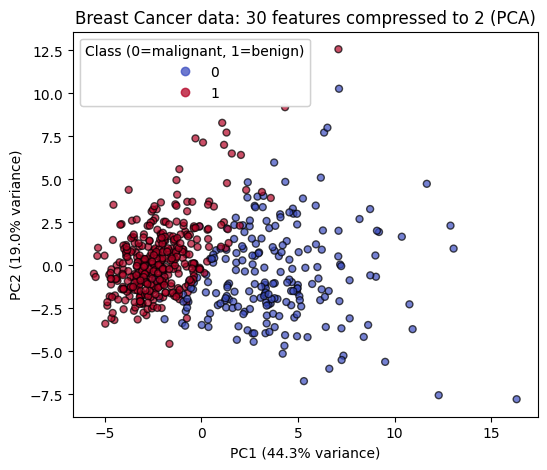

In [3]:
fig, ax = plt.subplots()
scatter = ax.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.7, edgecolor='k', s=25)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Breast Cancer data: 30 features compressed to 2 (PCA)')
legend1 = ax.legend(*scatter.legend_elements(), title="Class (0=malignant, 1=benign)")
ax.add_artist(legend1)
plt.show()

**Key takeaway:** even though PCA had no idea about the malignant/benign labels (it's unsupervised
— it only looked at feature spread), the two classes naturally separate quite well in just 2D. That's
a strong sign these 30 features genuinely carry information relevant to the diagnosis.

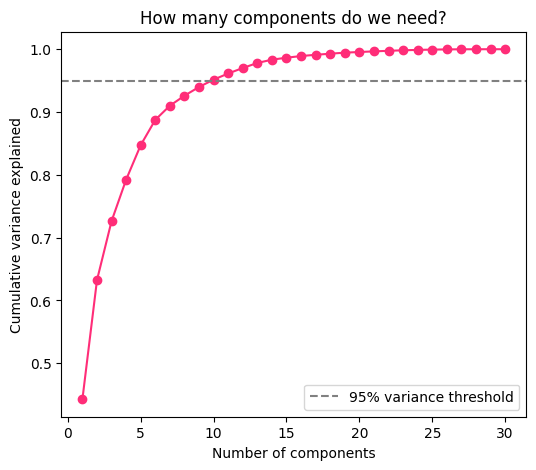

Components needed to capture 95% of variance: 10 (out of 30 original features)


In [4]:
# How many components do we actually need to capture "most" of the variance?
pca_full = PCA().fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'o-', color='#ff2d78')
plt.axhline(0.95, color='gray', linestyle='--', label='95% variance threshold')
plt.xlabel('Number of components'); plt.ylabel('Cumulative variance explained')
plt.title('How many components do we need?')
plt.legend()
plt.show()

n_for_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed to capture 95% of variance: {n_for_95} (out of 30 original features)")

**Connects to your project:** this "cumulative variance" plot is exactly how you'd decide, for
example, whether your stroke dataset's features could be compressed to fewer dimensions before feeding
them into a model — though in practice, with only ~10 features and a tree-based model like XGBoost,
you likely won't need PCA for training; it's mainly valuable here as a **visualization/exploration**
tool.

---
## 3. t-SNE (t-distributed Stochastic Neighbor Embedding)

PCA is linear — it can only find straight-line directions of variance. Some data has more complex,
curved/tangled structure that a straight line can't capture well. **t-SNE** takes a very different
approach: it looks at every pair of points and asks "how similar are these two, based on their
distance in the original high-dimensional space?" It then arranges points in 2D so that points which
were close in high dimensions stay close in 2D — even if that means stretching or distorting the
overall shape.

**Important distinction:** PCA distances are mathematically meaningful (they represent real variance).
t-SNE distances are **not** — it's built purely for visualization; you should never feed t-SNE output
into a downstream model, and you can't meaningfully compare distances between t-SNE clusters.

Shape: (1797, 64) (each row is one handwritten digit image, flattened)


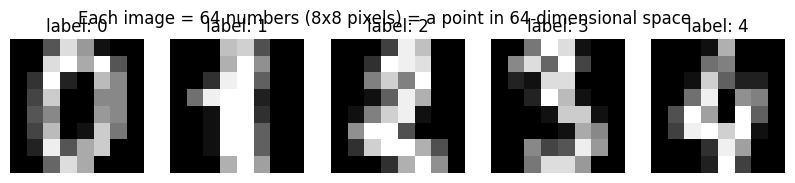

In [5]:
digits = load_digits()
X_digits = digits.data       # 1797 images, 64 features each (8x8 pixels flattened)
y_digits = digits.target     # actual digit 0-9

print("Shape:", X_digits.shape, "(each row is one handwritten digit image, flattened)")

# what one "data point" actually looks like before flattening
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"label: {digits.target[i]}")
    ax.axis('off')
plt.suptitle("Each image = 64 numbers (8x8 pixels) = a point in 64-dimensional space")
plt.show()

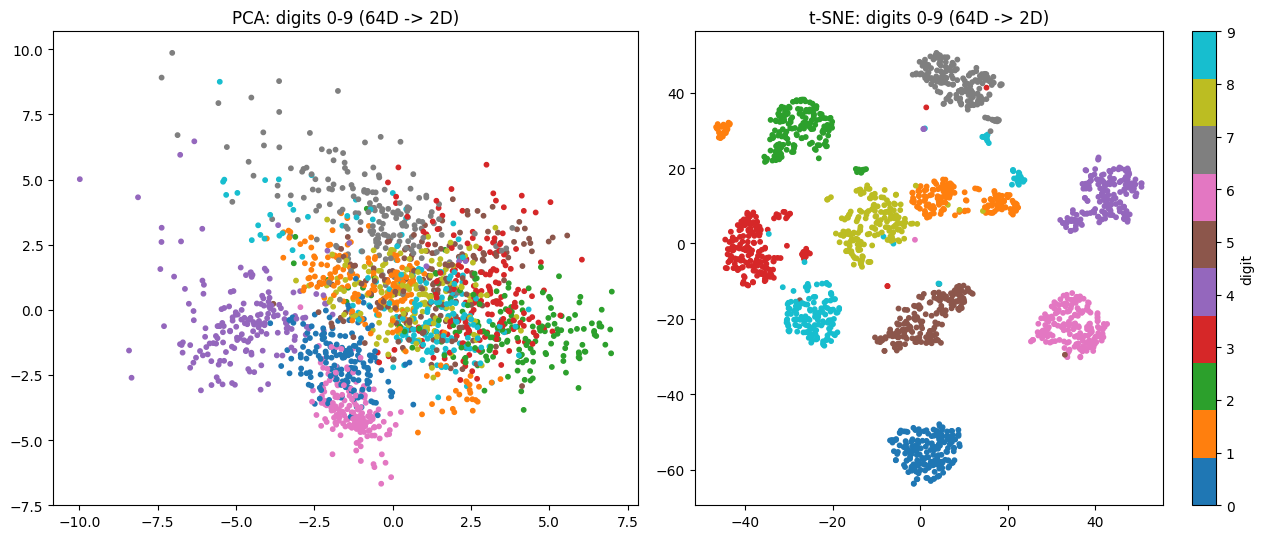

In [6]:
# PCA on the same data first, for comparison
X_digits_scaled = StandardScaler().fit_transform(X_digits)
pca_digits = PCA(n_components=2).fit_transform(X_digits_scaled)

# t-SNE - this is slower since it computes pairwise similarities for every point
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_digits)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sc1 = axes[0].scatter(pca_digits[:,0], pca_digits[:,1], c=y_digits, cmap='tab10', s=10)
axes[0].set_title("PCA: digits 0-9 (64D -> 2D)")

sc2 = axes[1].scatter(X_tsne[:,0], X_tsne[:,1], c=y_digits, cmap='tab10', s=10)
axes[1].set_title("t-SNE: digits 0-9 (64D -> 2D)")

plt.colorbar(sc2, ax=axes[1], label='digit')
plt.tight_layout()
plt.show()

**Key takeaway:** look at how much cleaner the t-SNE clusters are compared to PCA's overlapping
blob. PCA is forced to use straight-line directions of variance, so digits that "look similar" in
pixel space but aren't linearly separable (like 4, 7, 9) blur together. t-SNE explicitly optimizes for
"keep similar things close," so the 10 digit clusters separate far more cleanly — this is *why* t-SNE
became the go-to visualization tool for things like gene expression data, word embeddings, and image
features, where the structure is naturally non-linear.

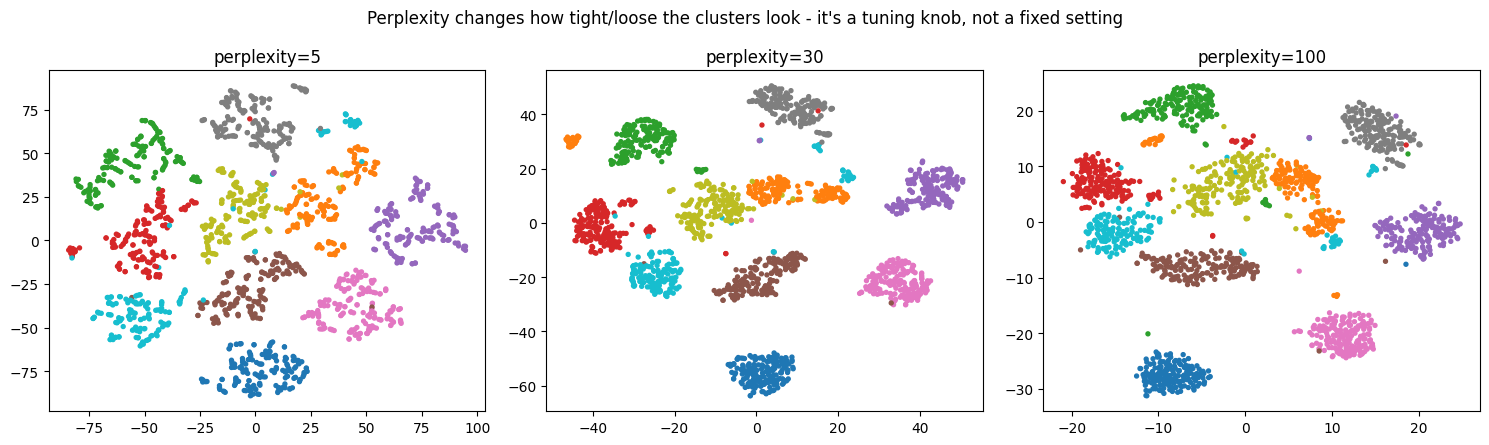

In [7]:
# perplexity controls how many neighbors t-SNE considers "local" - it matters a lot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, perp in zip(axes, [5, 30, 100]):
    tsne_p = TSNE(n_components=2, perplexity=perp, random_state=42)
    X_p = tsne_p.fit_transform(X_digits)
    ax.scatter(X_p[:,0], X_p[:,1], c=y_digits, cmap='tab10', s=8)
    ax.set_title(f"perplexity={perp}")
plt.suptitle("Perplexity changes how tight/loose the clusters look - it's a tuning knob, not a fixed setting")
plt.tight_layout()
plt.show()

---
## 4. PCA vs. t-SNE — When to Use Which

| | PCA | t-SNE |
|---|---|---|
| Type | Linear | Non-linear |
| Speed | Fast, scales well | Slow on large datasets |
| Distances meaningful? | Yes (real variance) | No (visualization only) |
| Can transform new/unseen data? | Yes | No — must rerun on the whole dataset |
| Good for | Quick exploration, preprocessing, feature compression before another model | Best possible 2D visualization of complex/clustered structure |
| Deterministic? | Yes, same result every run | No — different random seeds can give different-looking layouts |

**Rule of thumb:** start with PCA — it's fast and tells you how much variance even exists in fewer
dimensions. Reach for t-SNE specifically when you want the *clearest possible visual picture* of
whether your data has natural clusters, and you don't need to reuse the output anywhere else.